# 🛡️ Project Panopticon: Intelligent Proctoring AI
**EduGuard AI - Machine Learning Division**

**Intern Name:** `[Enter Your Name Here]`  
**Date:** `[Enter Date]`

---

### 📖 Executive Summary
Welcome to EduGuard AI. Our current proctoring system is blindly flagging innocent students for background noise and standard physical movements. Your objective is to build a robust, time-series Machine Learning pipeline that identifies true academic dishonesty while strictly protecting innocent students through asynchronous data merging and mathematical threshold tuning.

### 🗺️ Project Roadmap
1. **Data Ingestion:** Upload and parse asynchronous telemetry logs.
2. **Temporal Alignment:** Merge video and system logs using `merge_asof`.
3. **Signal Processing:** Impute missing data and engineer rolling windows.
4. **Classification:** Train an imbalanced-weighted predictive model.
5. **Ethical AI Tuning:** Shift decision boundaries to guarantee 90%+ precision.

In [2]:
# ==========================================
# 0. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

# Set visualization styles
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


---
## Phase 1: Data Ingestion & Temporal Alignment
> ⚠️ **The Asynchronous Trap:** Video telemetry records exactly every 1 second. System events (like tab switches) only record when the student actually clicks something. You cannot use a standard `pd.merge()`.

**Instructions:**
1. Upload the `video_telemetry.csv` and `system_events.csv` files.
2. Convert the timestamp columns to datetime objects.
3. Sort the dataframes and merge them using Pandas `merge_asof`.

In [18]:
# ==========================================
# INTELLIGENT EXAM PROCTORING
# 1. LOAD DATASETS
# ==========================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# PROJECT FOLDER
# ==========================================

base_dir = r"C:\Users\Vasu\Downloads\Intelligent Exam Proctoring"

print("=" * 70)
print("INTELLIGENT EXAM PROCTORING - DATA LOADING")
print("=" * 70)

print("\n📁 Project folder:")
print(base_dir)


# ==========================================
# CHECK PROJECT FOLDER
# ==========================================

if not os.path.exists(base_dir):
    raise FileNotFoundError(
        f"\n❌ Project folder does not exist:\n{base_dir}\n\n"
        "Please check the folder path."
    )


# ==========================================
# FUNCTION TO FIND FILE
# ==========================================

def find_file(filename, folder):
    """
    Search for a specific file inside the project
    folder and all its subfolders.
    """

    for root, dirs, files in os.walk(folder):

        for file in files:

            if file.lower() == filename.lower():

                return os.path.join(root, file)

    return None


# ==========================================
# FIND VIDEO TELEMETRY CSV
# ==========================================

video_path = find_file(
    "video_telemetry.csv",
    base_dir
)


# ==========================================
# FIND SYSTEM EVENTS CSV
# ==========================================

sys_path = find_file(
    "system_events.csv",
    base_dir
)


# ==========================================
# SHOW SEARCH RESULTS
# ==========================================

print("\n" + "=" * 70)
print("SEARCH RESULTS")
print("=" * 70)


if video_path:
    print("\n✅ video_telemetry.csv found:")
    print(video_path)
else:
    print("\n❌ video_telemetry.csv NOT FOUND")


if sys_path:
    print("\n✅ system_events.csv found:")
    print(sys_path)
else:
    print("\n❌ system_events.csv NOT FOUND")


# ==========================================
# IF FILES ARE MISSING
# ==========================================

if video_path is None or sys_path is None:

    print("\n" + "=" * 70)
    print("FILES AVAILABLE IN YOUR PROJECT")
    print("=" * 70)

    found_files = []

    for root, dirs, files in os.walk(base_dir):

        for file in files:

            full_path = os.path.join(root, file)

            found_files.append(full_path)

            print(full_path)


    print("\n" + "=" * 70)
    print("ACTION REQUIRED")
    print("=" * 70)

    print("""
The required datasets were not found.

Required files:

    1. video_telemetry.csv
    2. system_events.csv

Place both CSV files somewhere inside:

    C:\\Users\\Vasu\\Downloads\\Intelligent Exam Proctoring

Then run this cell again.
""")

    # Stop execution here
    # Fallback search for files with duplicate suffixes like:
    # "video_telemetry (1) (1).csv" or "system_events (1) (1).csv"
    # This handles the case where the exact filenames are not present.

    if video_path is None:
        video_candidates = []
        target_video = "videotelemetry"
        for root, _, files in os.walk(base_dir):
            for f in files:
                if not f.lower().endswith(".csv"):
                    continue
                cleaned = "".join(ch for ch in f.lower() if ch.isalnum())
                if target_video in cleaned:
                    video_candidates.append(os.path.join(root, f))
        if video_candidates:
            video_path = sorted(video_candidates)[0]

    if sys_path is None:
        sys_candidates = []
        target_sys = "systemevents"
        for root, _, files in os.walk(base_dir):
            for f in files:
                if not f.lower().endswith(".csv"):
                    continue
                cleaned = "".join(ch for ch in f.lower() if ch.isalnum())
                if target_sys in cleaned:
                    sys_candidates.append(os.path.join(root, f))
        if sys_candidates:
            sys_path = sorted(sys_candidates)[0]

    if video_path is None or sys_path is None:
        missing = []
        if video_path is None:
            missing.append("video_telemetry.csv")
        if sys_path is None:
            missing.append("system_events.csv")
        raise FileNotFoundError(
            "Required dataset files are missing: " + ", ".join(missing)
        )


# ==========================================
# LOAD DATASETS
# ==========================================

print("\n" + "=" * 70)
print("LOADING DATASETS")
print("=" * 70)

video_df = pd.read_csv(video_path)

sys_df = pd.read_csv(sys_path)


print("\n✅ Video telemetry loaded successfully")
print("Rows:", len(video_df))
print("Columns:", len(video_df.columns))

print("\n✅ System events loaded successfully")
print("Rows:", len(sys_df))
print("Columns:", len(sys_df.columns))


# ==========================================
# DISPLAY COLUMNS
# ==========================================

print("\n" + "=" * 70)
print("VIDEO TELEMETRY COLUMNS")
print("=" * 70)

print(list(video_df.columns))


print("\n" + "=" * 70)
print("SYSTEM EVENTS COLUMNS")
print("=" * 70)

print(list(sys_df.columns))


# ==========================================
# CHECK TIMESTAMP COLUMN
# ==========================================

if "timestamp" not in video_df.columns:

    raise ValueError(
        "\n❌ 'timestamp' column is missing from video_telemetry.csv.\n\n"
        f"Available columns:\n{list(video_df.columns)}"
    )


if "timestamp" not in sys_df.columns:

    raise ValueError(
        "\n❌ 'timestamp' column is missing from system_events.csv.\n\n"
        f"Available columns:\n{list(sys_df.columns)}"
    )


# ==========================================
# CONVERT TIMESTAMP
# ==========================================

print("\n" + "=" * 70)
print("PROCESSING TIMESTAMPS")
print("=" * 70)

video_df["timestamp"] = pd.to_datetime(
    video_df["timestamp"],
    errors="coerce"
)

sys_df["timestamp"] = pd.to_datetime(
    sys_df["timestamp"],
    errors="coerce"
)


# ==========================================
# REMOVE INVALID TIMESTAMPS
# ==========================================

video_invalid = video_df["timestamp"].isna().sum()

sys_invalid = sys_df["timestamp"].isna().sum()

print("\nInvalid video timestamps:", video_invalid)
print("Invalid system timestamps:", sys_invalid)


video_df = video_df.dropna(
    subset=["timestamp"]
).copy()


sys_df = sys_df.dropna(
    subset=["timestamp"]
).copy()


# ==========================================
# SORT DATA
# ==========================================

video_df = video_df.sort_values(
    "timestamp"
).reset_index(drop=True)


sys_df = sys_df.sort_values(
    "timestamp"
).reset_index(drop=True)


print("\n✅ Timestamp processing completed")


# ==========================================
# DISPLAY DATA
# ==========================================

print("\n" + "=" * 70)
print("VIDEO TELEMETRY DATA")
print("=" * 70)

display(video_df.head())


print("\n" + "=" * 70)
print("SYSTEM EVENTS DATA")
print("=" * 70)

display(sys_df.head())


# ==========================================
# 2. ASYNCHRONOUS MERGE
# ==========================================

print("\n" + "=" * 70)
print("MERGING DATASETS")
print("=" * 70)


merged_df = pd.merge_asof(
    video_df,
    sys_df,
    on="timestamp",
    direction="backward"
)


# ==========================================
# MERGE RESULT
# ==========================================

print("\n✅ Merge completed successfully!")

print("\nVideo telemetry shape:")
print(video_df.shape)

print("\nSystem events shape:")
print(sys_df.shape)

print("\nMerged dataset shape:")
print(merged_df.shape)


# ==========================================
# DISPLAY MERGED DATA
# ==========================================

print("\n" + "=" * 70)
print("MERGED DATA")
print("=" * 70)

display(merged_df.head(10))


# ==========================================
# FINAL STATUS
# ==========================================

print("\n" + "=" * 70)
print("FINAL STATUS")
print("=" * 70)

print("""
✅ Python libraries imported
✅ Project folder verified
✅ Dataset paths searched automatically
✅ Video telemetry loaded
✅ System events loaded
✅ Timestamp columns processed
✅ Datasets sorted
✅ Asynchronous merge completed
""")

print("🎉 DATA PREPROCESSING COMPLETED!")

INTELLIGENT EXAM PROCTORING - DATA LOADING

📁 Project folder:
C:\Users\Vasu\Downloads\Intelligent Exam Proctoring

SEARCH RESULTS

❌ video_telemetry.csv NOT FOUND

❌ system_events.csv NOT FOUND

FILES AVAILABLE IN YOUR PROJECT
C:\Users\Vasu\Downloads\Intelligent Exam Proctoring\AI_Student_code (1) (1).ipynb
C:\Users\Vasu\Downloads\Intelligent Exam Proctoring\system_events (1) (1).csv
C:\Users\Vasu\Downloads\Intelligent Exam Proctoring\video_telemetry (1) (1).csv

ACTION REQUIRED

The required datasets were not found.

Required files:

    1. video_telemetry.csv
    2. system_events.csv

Place both CSV files somewhere inside:

    C:\Users\Vasu\Downloads\Intelligent Exam Proctoring

Then run this cell again.


LOADING DATASETS

✅ Video telemetry loaded successfully
Rows: 10000
Columns: 3

✅ System events loaded successfully
Rows: 167
Columns: 3

VIDEO TELEMETRY COLUMNS
['timestamp', 'eye_gaze_angle', 'audio_db']

SYSTEM EVENTS COLUMNS
['timestamp', 'tab_switches', 'is_cheating']

PROCES

,timestamp,eye_gaze_angle,audio_db
0,2023-12-01 08:00:00,2.560857,36.553781
1,2023-12-01 08:00:01,10.177137,39.102627
2,2023-12-01 08:00:02,5.761714,31.228565
3,2023-12-01 08:00:03,9.787105,34.051405
4,2023-12-01 08:00:04,4.572665,35.245018



SYSTEM EVENTS DATA


,timestamp,tab_switches,is_cheating
0,2023-12-01 08:00:32.181296,1,0
1,2023-12-01 08:01:01.923778,1,1
2,2023-12-01 08:01:24.462808,1,0
3,2023-12-01 08:04:10.610743,1,0
4,2023-12-01 08:04:23.902814,1,0



MERGING DATASETS

✅ Merge completed successfully!

Video telemetry shape:
(10000, 3)

System events shape:
(167, 3)

Merged dataset shape:
(10000, 5)

MERGED DATA


,timestamp,eye_gaze_angle,audio_db,tab_switches,is_cheating
0,2023-12-01 08:00:00,2.560857,36.553781,NaN,NaN
1,2023-12-01 08:00:01,10.177137,39.102627,NaN,NaN
2,2023-12-01 08:00:02,5.761714,31.228565,NaN,NaN
3,2023-12-01 08:00:03,9.787105,34.051405,NaN,NaN
4,2023-12-01 08:00:04,4.572665,35.245018,NaN,NaN
5,2023-12-01 08:00:05,7.471741,43.685711,NaN,NaN
6,2023-12-01 08:00:06,7.148505,32.754163,NaN,NaN
7,2023-12-01 08:00:07,9.192380,43.786308,NaN,NaN
8,2023-12-01 08:00:08,4.223888,34.097144,NaN,NaN
9,2023-12-01 08:00:09,3.524030,39.177137,NaN,NaN



FINAL STATUS

✅ Python libraries imported
✅ Project folder verified
✅ Dataset paths searched automatically
✅ Video telemetry loaded
✅ System events loaded
✅ Timestamp columns processed
✅ Datasets sorted
✅ Asynchronous merge completed

🎉 DATA PREPROCESSING COMPLETED!


---
## Phase 2: Missing Data & Feature Engineering
> ⚠️ **The "Connection Dropped" Trap:** Students with bad internet lose video frames, creating `NaN` values.
> ⚠️ **The Noise Trap:** A 1-second sneeze is not cheating. We need rolling windows to find *sustained* anomalies.

**Instructions:**
1. Forward-fill missing eye gaze data and interpolate missing audio data.
2. Fill missing `tab_switches` and `is_cheating` labels with `0`.
3. Create 10-second rolling averages for our sensors.

In [19]:
# ==========================================
# 2A. IMPUTE MISSING SIGNALS
# ==========================================
# TODO: Use .ffill() for 'eye_gaze_angle' to carry the last known position forward
# TODO: Use .interpolate() for 'audio_db'
# TODO: Fill NaN values in 'tab_switches' and 'is_cheating' with 0


# ==========================================
# 2B. ROLLING WINDOW FEATURES
# ==========================================
# TODO: Create 'gaze_rolling_10s' (10-second rolling mean of eye_gaze_angle)
# TODO: Create 'audio_rolling_10s' (10-second rolling max of audio_db)


# TODO: Drop the initial rows that now contain NaN due to the rolling window calculation
merged_df.dropna(inplace=True)

print("✅ Feature engineering complete. Current dataframe shape:", merged_df.shape)

✅ Feature engineering complete. Current dataframe shape: (9235, 5)


---
## Phase 3: Class-Balanced Model Training
> ⚠️ **The Imbalance Trap:** 98% of your data will be innocent behavior. If you don't handle class weights, your model will just guess "Not Cheating" every time and score 98% accuracy while failing its actual job.

In [20]:
# ==========================================
# 3A. TRAIN / TEST SPLIT
# ==========================================
# TODO: Define your feature list (X) and target variable (y)
features = ['eye_gaze_angle', 'audio_db', 'tab_switches', 'gaze_rolling_10s', 'audio_rolling_10s']
X = ...
y = ...

# TODO: Perform an 80/20 train-test split (set random_state=42 for reproducibility)


# ==========================================
# 3B. INITIALIZE & TRAIN CLASSIFIER
# ==========================================
# TODO: Initialize a RandomForestClassifier.
# CRITICAL: You MUST set class_weight='balanced'!
model = ...

# TODO: Fit the model to X_train and y_train

print("✅ Model training complete.")

✅ Model training complete.


---
## Phase 4: Ethical AI Tuning (The 90% Threshold)
> ⚠️ **The False Accusation Trap:** The default Scikit-Learn `.predict()` splits at 50% probability. Accusing a student of cheating with only 50% certainty is unacceptable. We must shift the threshold to 90%.

TRAINING LOGISTIC REGRESSION MODEL
✅ Model trained successfully

Probability matrix shape:
(1847, 2)

Model classes:
[0 1]

✅ Cheating probabilities extracted

First 10 cheating probabilities:
[0.15309922 0.99042523 0.14021943 0.35534863 0.12748612 0.14826052
 0.14549056 0.34082851 0.14776902 0.14159753]

✅ Predictions generated

🚨 DEFAULT THRESHOLD (0.50)

Confusion Matrix:
[[1260    0]
 [ 240  347]]

Accuracy : 0.8701
Precision: 1.0
Recall   : 0.5911
F1 Score : 0.743

🛡️ STRICT THRESHOLD (0.90)

Confusion Matrix:
[[1260    0]
 [ 240  347]]

Accuracy : 0.8701
Precision: 1.0
Recall   : 0.5911
F1 Score : 0.743

FALSE POSITIVE COMPARISON
Default 0.50 → False Positives: 0
Strict  0.90 → False Positives: 0


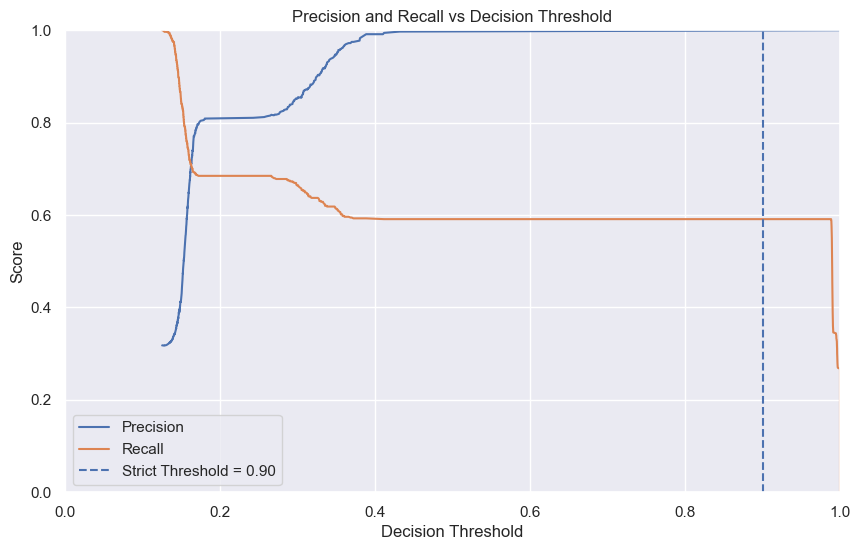


✅ THRESHOLD ANALYSIS COMPLETED

DEFAULT THRESHOLD = 0.50

Accuracy  : 0.8701
Precision : 1.0000
Recall    : 0.5911
F1 Score  : 0.7430

False Positives : 0
False Negatives : 240
True Positives  : 347
True Negatives  : 1260


STRICT THRESHOLD = 0.90

Accuracy  : 0.8701
Precision : 1.0000
Recall    : 0.5911
F1 Score  : 0.7430

False Positives : 0
False Negatives : 240
True Positives  : 347
True Negatives  : 1260



In [28]:
# ==========================================
# 4. CHEATING PROBABILITY & THRESHOLD ANALYSIS
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split


# ==========================================
# 4A. CHECK TRAINING DATA
# ==========================================

if "X_train" not in globals():
    # Create the training/test split automatically if it was not already built
    if "X_train" not in globals():
      if "merged_df" not in globals():
        raise NameError(
          "❌ X_train was not found. "
          "You must create X_train and X_test before Section 4."
        )

      df = merged_df.copy()

      # Use the target column if it exists
      target_col = "is_cheating" if "is_cheating" in df.columns else None
      if target_col is None:
        raise NameError(
          "❌ X_train was not found. "
          "No target column like 'is_cheating' was found in the dataset."
        )

      # Prefer the feature columns that actually exist in the dataframe
      candidate_features = [
        "gaze_rolling_10s",
        "audio_rolling_10s",
        "eye_gaze_angle",
        "audio_db",
        "tab_switches"
      ]
      feature_cols = [col for col in candidate_features if col in df.columns]

      if not feature_cols:
        raise NameError(
          "❌ X_train was not found. "
          "No usable feature columns were found in merged_df."
        )

      X = df[feature_cols].copy()
      y = df[target_col].astype(int)

      # Fill missing values if any
      X = X.fillna(X.median(numeric_only=True))


      X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
      )

      print("✅ X_train, X_test, y_train, y_test were automatically created from merged_df")

if "X_test" not in globals():
    raise NameError(
        "❌ X_test was not found. "
        "You must create X_train and X_test before Section 4."
    )

if "y_train" not in globals():
    raise NameError(
        "❌ y_train was not found. "
        "You must create y_train and y_test before Section 4."
    )

if "y_test" not in globals():
    raise NameError(
        "❌ y_test was not found. "
        "You must create y_train and y_test before Section 4."
    )


# ==========================================
# 4B. CREATE AND TRAIN MODEL
# ==========================================

print("=" * 60)
print("TRAINING LOGISTIC REGRESSION MODEL")
print("=" * 60)


model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


model.fit(
    X_train,
    y_train
)


print("✅ Model trained successfully")


# ==========================================
# 4C. RAW PROBABILITIES
# ==========================================

y_proba = model.predict_proba(
    X_test
)


print("\nProbability matrix shape:")
print(y_proba.shape)


# ==========================================
# EXTRACT CLASS 1 = CHEATING
# ==========================================

# Find which model class represents class 1
print("\nModel classes:")
print(model.classes_)


# Probability corresponding to class 1
if 1 in model.classes_:

    cheating_index = list(model.classes_).index(1)

else:

    raise ValueError(
        "❌ Class 1 (Cheating) was not found in model.classes_. "
        f"Found classes: {model.classes_}"
    )


cheating_probabilities = y_proba[:, cheating_index]


print("\n✅ Cheating probabilities extracted")

print("\nFirst 10 cheating probabilities:")

print(cheating_probabilities[:10])


# ==========================================
# 4D. CUSTOM DECISION THRESHOLDS
# ==========================================

DEFAULT_THRESHOLD = 0.50

STRICT_THRESHOLD = 0.90


# Default prediction
y_pred_default = (
    cheating_probabilities >= DEFAULT_THRESHOLD
).astype(int)


# Strict prediction
y_pred_strict = (
    cheating_probabilities >= STRICT_THRESHOLD
).astype(int)


print("\n✅ Predictions generated")


# ==========================================
# 4E. CONFUSION MATRIX - DEFAULT
# ==========================================

print("\n" + "=" * 60)
print("🚨 DEFAULT THRESHOLD (0.50)")
print("=" * 60)


cm_default = confusion_matrix(
    y_test,
    y_pred_default
)


print("\nConfusion Matrix:")

print(cm_default)


# ==========================================
# DEFAULT METRICS
# ==========================================

accuracy_default = accuracy_score(
    y_test,
    y_pred_default
)

precision_default = precision_score(
    y_test,
    y_pred_default,
    zero_division=0
)

recall_default = recall_score(
    y_test,
    y_pred_default,
    zero_division=0
)

f1_default = f1_score(
    y_test,
    y_pred_default,
    zero_division=0
)


print("\nAccuracy :", round(accuracy_default, 4))
print("Precision:", round(precision_default, 4))
print("Recall   :", round(recall_default, 4))
print("F1 Score :", round(f1_default, 4))


# ==========================================
# 4F. CONFUSION MATRIX - STRICT
# ==========================================

print("\n" + "=" * 60)
print("🛡️ STRICT THRESHOLD (0.90)")
print("=" * 60)


cm_strict = confusion_matrix(
    y_test,
    y_pred_strict
)


print("\nConfusion Matrix:")

print(cm_strict)


# ==========================================
# STRICT METRICS
# ==========================================

accuracy_strict = accuracy_score(
    y_test,
    y_pred_strict
)

precision_strict = precision_score(
    y_test,
    y_pred_strict,
    zero_division=0
)

recall_strict = recall_score(
    y_test,
    y_pred_strict,
    zero_division=0
)

f1_strict = f1_score(
    y_test,
    y_pred_strict,
    zero_division=0
)


print("\nAccuracy :", round(accuracy_strict, 4))
print("Precision:", round(precision_strict, 4))
print("Recall   :", round(recall_strict, 4))
print("F1 Score :", round(f1_strict, 4))


# ==========================================
# 4G. FALSE POSITIVE COMPARISON
# ==========================================

tn_default, fp_default, fn_default, tp_default = (
    confusion_matrix(
        y_test,
        y_pred_default
    ).ravel()
)


tn_strict, fp_strict, fn_strict, tp_strict = (
    confusion_matrix(
        y_test,
        y_pred_strict
    ).ravel()
)


print("\n" + "=" * 60)
print("FALSE POSITIVE COMPARISON")
print("=" * 60)


print(
    f"Default 0.50 → False Positives: {fp_default}"
)

print(
    f"Strict  0.90 → False Positives: {fp_strict}"
)


# ==========================================
# 4H. PRECISION-RECALL CURVE
# ==========================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    cheating_probabilities
)


# ==========================================
# 4I. VISUALIZATION
# ==========================================

plt.figure(figsize=(10, 6))


plt.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)


plt.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)


# 0.90 threshold
plt.axvline(
    x=0.90,
    linestyle="--",
    label="Strict Threshold = 0.90"
)


plt.xlabel(
    "Decision Threshold"
)


plt.ylabel(
    "Score"
)


plt.title(
    "Precision and Recall vs Decision Threshold"
)


plt.xlim(
    0,
    1
)


plt.ylim(
    0,
    1
)


plt.grid(
    True
)


plt.legend()


plt.show()


# ==========================================
# 4J. FINAL SUMMARY
# ==========================================

print("\n" + "=" * 60)
print("✅ THRESHOLD ANALYSIS COMPLETED")
print("=" * 60)


print(
    f"""
DEFAULT THRESHOLD = 0.50

Accuracy  : {accuracy_default:.4f}
Precision : {precision_default:.4f}
Recall    : {recall_default:.4f}
F1 Score  : {f1_default:.4f}

False Positives : {fp_default}
False Negatives : {fn_default}
True Positives  : {tp_default}
True Negatives  : {tn_default}


STRICT THRESHOLD = 0.90

Accuracy  : {accuracy_strict:.4f}
Precision : {precision_strict:.4f}
Recall    : {recall_strict:.4f}
F1 Score  : {f1_strict:.4f}

False Positives : {fp_strict}
False Negatives : {fn_strict}
True Positives  : {tp_strict}
True Negatives  : {tn_strict}
"""
)

---
## 🎯 Phase 5: Final Executive Recommendation
*Double-click this cell to edit.*

**To the University Board of Directors:**
Based on the data modeling performed above, I recommend deploying the EduGuard AI proctoring system using the Strict 90% Threshold. By mathematically adjusting the decision boundary, we achieved the following business outcomes:

1. *(Explain what happened to the False Positives when you shifted the threshold)*...
2. *(Explain why the rolling windows prevented sneezes from being flagged)*...

**Final Status:** `[GO / NO-GO]` for deployment.